In [22]:
import torch
import tiktoken
import matplotlib.pyplot as plt
enc=tiktoken.get_encoding('gpt2')

In [23]:
from train_gpt2 import GPT2Config,GPT2
checkpoint=torch.load("gpt2_step_11500.pt",map_location="cpu")
for key in list(checkpoint.keys()):
    if key.startswith('_orig_mod.'):
        checkpoint[key[len('_orig_mod.'):]]=checkpoint.pop(key)

model=GPT2(GPT2Config())
model.load_state_dict(checkpoint,strict=False)

_IncompatibleKeys(missing_keys=['transformer.h.0.attn.bias', 'transformer.h.1.attn.bias', 'transformer.h.2.attn.bias', 'transformer.h.3.attn.bias', 'transformer.h.4.attn.bias', 'transformer.h.5.attn.bias', 'transformer.h.6.attn.bias', 'transformer.h.7.attn.bias', 'transformer.h.8.attn.bias', 'transformer.h.9.attn.bias', 'transformer.h.10.attn.bias', 'transformer.h.11.attn.bias'], unexpected_keys=[])

In [24]:
text="The scientist carefully examined the results of the experiment and noticed that several measurements differed from the original hypothesis. Although the data appeared noisy at first, further analysis revealed a consistent pattern across multiple trials. The researchers discussed possible explanations, compared their findings with previous studies, and concluded that additional experiments would be necessary to fully understand the underlying phenomenon."
tokens_tensor=torch.tensor((enc.encode(text))).unsqueeze(0)
with torch.no_grad():
    outputs,_=model(tokens_tensor)
print(outputs.shape)

torch.Size([1, 66, 50304])


In [25]:
eps=1e-12
layer_entropies=[]
for i in range(12):
    att=model.transformer.h[i].attn.last_att
    head_entropies=[]
    for j in range(att.size(1)):
        head=att[0,j]
        entropies=[]
        for k in range(head.size(0)):
            row=head[k]
            entropy=-(row*torch.log(row+eps)).sum()
            entropies.append(entropy)
        head_entropies.append(sum(entropies)/len(entropies))
    layer_entropies.append(sum(head_entropies)/len(head_entropies))

print(layer_entropies)

[tensor(3.1138632298), tensor(2.1885530949), tensor(2.2996916771), tensor(2.1650242805), tensor(1.8311687708), tensor(1.7732738256), tensor(1.5365810394), tensor(1.8494035006), tensor(1.3830891848), tensor(1.8253498077), tensor(1.4470566511), tensor(1.9515565634)]


In [26]:
for i in range(12):
    att_0=model.transformer.h[i].attn.last_att
    head_entropies=[]
    for j in range(att_0.size(1)):
        head=att_0[0,j]
        entropies=[]
        for k in range(head.size(0)):
            row=head[k]
            entropy=-(row*torch.log(row+eps)).sum()
            entropies.append(entropy)
        head_entropies.append((sum(entropies)/len(entropies)).item())
    print(head_entropies)

[3.076305627822876, 3.0789146423339844, 3.099788188934326, 3.172985076904297, 3.152137041091919, 3.08752179145813, 3.0770790576934814, 3.125051736831665, 3.0786383152008057, 3.1405770778656006, 3.089900255203247, 3.187462329864502]
[2.9164960384368896, 2.7491791248321533, 1.7242224216461182, 1.6070634126663208, 1.9909753799438477, 2.336989641189575, 1.4579294919967651, 2.018369197845459, 1.7275913953781128, 1.8819000720977783, 2.7727413177490234, 3.0791819095611572]
[2.9283487796783447, 2.368431329727173, 1.7084579467773438, 2.2204015254974365, 2.754812240600586, 2.8716208934783936, 2.8221182823181152, 2.204240322113037, 2.2570950984954834, 1.6978271007537842, 1.0270134210586548, 2.7359328269958496]
[2.3574109077453613, 2.4397802352905273, 2.144780397415161, 2.6757302284240723, 1.7631072998046875, 2.158379316329956, 2.882038116455078, 2.1538631916046143, 2.5863757133483887, 1.3095277547836304, 1.7360645532608032, 1.773232102394104]
[1.3842178583145142, 1.1043176651000977, 2.22052574157

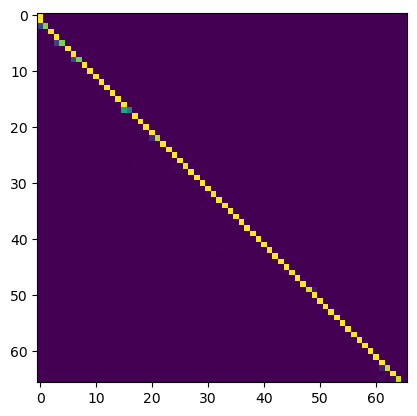

In [27]:
att_5=model.transformer.h[5].attn.last_att
head=att_5[0,3]
plt.imshow(head)

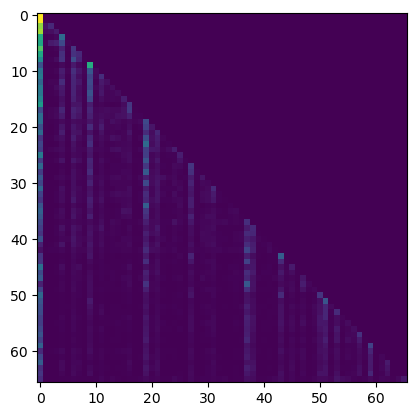

In [28]:
head_3=att_5[0,5]
plt.imshow(head_3)

In [29]:
sim_tensor=torch.zeros((12,12))

In [30]:
for i in range(12):
    head_1=att_5[0,i].view(-1)
    for j in range(12):
        head_2=att_5[0,j].view(-1)
        cos_sim=torch.dot(head_1,head_2)/(torch.norm(head_1)*torch.norm(head_2))
        sim_tensor[i,j]=cos_sim

print(sim_tensor)

tensor([[1.0000003576, 0.5278775096, 0.4483629465, 0.4030172825, 0.5231413841,
         0.3963509798, 0.4370773733, 0.4401833713, 0.2812065184, 0.5516055822,
         0.4797189236, 0.5156016350],
        [0.5278775096, 1.0000007153, 0.4778684974, 0.2427928895, 0.5211653709,
         0.5993415117, 0.5727713704, 0.4969183505, 0.5255820155, 0.4726284444,
         0.6400903463, 0.6211956143],
        [0.4483629465, 0.4778684974, 1.0000003576, 0.4466415644, 0.5342710614,
         0.3055762053, 0.4639180899, 0.5898096561, 0.1893982440, 0.4509374797,
         0.3929786980, 0.5482400656],
        [0.4030172825, 0.2427928895, 0.4466415644, 1.0000002384, 0.2061793357,
         0.1718426496, 0.3170419335, 0.2648871541, 0.0972927213, 0.4268720448,
         0.2384133190, 0.3186372817],
        [0.5231413841, 0.5211653709, 0.5342710614, 0.2061793357, 1.0000004768,
         0.5959330797, 0.3617905378, 0.5789126754, 0.4286510944, 0.3618033826,
         0.3425283730, 0.5184065700],
        [0.396350979

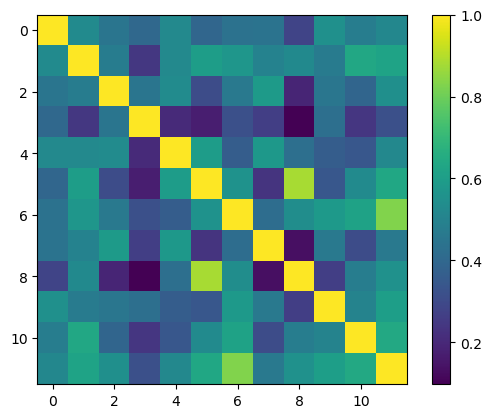

In [31]:
plt.imshow(sim_tensor)
plt.colorbar()

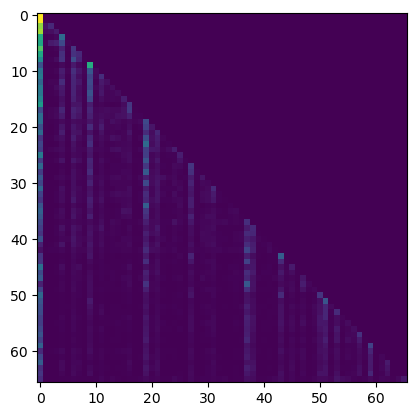

In [32]:
plt.imshow(att_5[0,5])


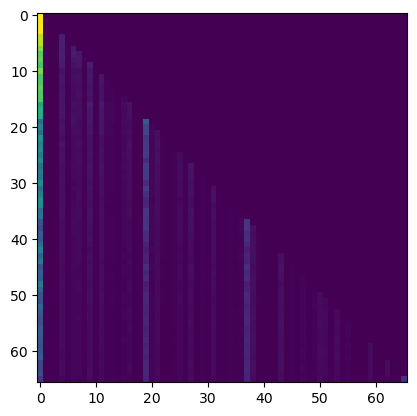

In [33]:
plt.imshow(att_5[0,8])

In [34]:
x=tokens_tensor[:,:-1]
y=tokens_tensor[:,1:]

with torch.no_grad():
    logits,base_loss=model(x,y)
torch.set_printoptions(precision=10)
print(base_loss)

tensor(3.1169035435)


In [35]:
from train_gpt2 import GPT2,GPT2Config
checkpoint=torch.load("gpt2_step_11500.pt",map_location="cpu")
for key in list(checkpoint.keys()):
    if key.startswith('_orig_mod.'):
        checkpoint[key[len('_orig_mod.'):]]=checkpoint.pop(key)

ablated_5_model=GPT2(GPT2Config())
ablated_5_model.load_state_dict(checkpoint,strict=False)

_IncompatibleKeys(missing_keys=['transformer.h.0.attn.bias', 'transformer.h.1.attn.bias', 'transformer.h.2.attn.bias', 'transformer.h.3.attn.bias', 'transformer.h.4.attn.bias', 'transformer.h.5.attn.bias', 'transformer.h.6.attn.bias', 'transformer.h.7.attn.bias', 'transformer.h.8.attn.bias', 'transformer.h.9.attn.bias', 'transformer.h.10.attn.bias', 'transformer.h.11.attn.bias'], unexpected_keys=[])

In [36]:
for i in range(12):
    ablated_5_model.transformer.h[5].attn.ablated_head=i
    with torch.no_grad():
        logits,ablated_5_loss=ablated_5_model(x,y)
    print(torch.abs(ablated_5_loss-base_loss))
    ablated_5_model.transformer.h[5].attn.ablated_head=None

ABLATING 0
tensor(0.0081501007)
ABLATING 1
tensor(0.0022413731)
ABLATING 2
tensor(0.0177164078)
ABLATING 3
tensor(0.1026296616)
ABLATING 4
tensor(0.0112180710)
ABLATING 5
tensor(0.0003385544)
ABLATING 6
tensor(0.0118453503)
ABLATING 7
tensor(0.0002770424)
ABLATING 8
tensor(0.0020017624)
ABLATING 9
tensor(0.0237483978)
ABLATING 10
tensor(0.0402181149)
ABLATING 11
tensor(0.0106966496)


In [37]:
from train_gpt2 import GPT2,GPT2Config
checkpoint=torch.load("gpt2_step_11500.pt",map_location="cpu")
for key in list(checkpoint.keys()):
    if key.startswith('_orig_mod.'):
        checkpoint[key[len('_orig_mod.'):]]=checkpoint.pop(key)

ablated_head_model=GPT2(GPT2Config())
ablated_head_model.load_state_dict(checkpoint,strict=False)

_IncompatibleKeys(missing_keys=['transformer.h.0.attn.bias', 'transformer.h.1.attn.bias', 'transformer.h.2.attn.bias', 'transformer.h.3.attn.bias', 'transformer.h.4.attn.bias', 'transformer.h.5.attn.bias', 'transformer.h.6.attn.bias', 'transformer.h.7.attn.bias', 'transformer.h.8.attn.bias', 'transformer.h.9.attn.bias', 'transformer.h.10.attn.bias', 'transformer.h.11.attn.bias'], unexpected_keys=[])

In [38]:
for i in range(12):
    print(f"For layer {i}")
    att_0=model.transformer.h[i].attn.last_att
    head_entropies=[]
    for j in range(att_0.size(1)):
        head=att_0[0,j]
        entropies=[]
        for k in range(head.size(0)):
            row=head[k]
            entropy=-(row*torch.log(row+eps)).sum()
            entropies.append(entropy)
        head_entropies.append((sum(entropies)/len(entropies)).item())
    min_value=min(head_entropies)
    min_index=head_entropies.index(min_value)
    max_value=max(head_entropies)
    max_index=head_entropies.index(max_value)
    ablated_head_model.transformer.h[i].attn.ablated_head=min_index
    with torch.no_grad():
        logits,ablated_head_loss=ablated_head_model(x,y)
    print(torch.abs(ablated_head_loss-base_loss))
    ablated_head_model.transformer.h[i].attn.ablated_head=max_index
    with torch.no_grad():
        logits,ablated_head_loss=ablated_head_model(x,y)
    print(torch.abs(ablated_head_loss-base_loss))
    ablated_head_model.transformer.h[i].attn.ablated_head=None   

For layer 0
ABLATING 0
tensor(0.0129904747)
ABLATING 11
tensor(0.2752325535)
For layer 1
ABLATING 6
tensor(0.0008442402)
ABLATING 11
tensor(0.0080177784)
For layer 2
ABLATING 10
tensor(0.0149931908)
ABLATING 0
tensor(0.0397350788)
For layer 3
ABLATING 9
tensor(0.0154526234)
ABLATING 6
tensor(0.0061693192)
For layer 4
ABLATING 1
tensor(0.0151965618)
ABLATING 7
tensor(0.0038464069)
For layer 5
ABLATING 3
tensor(0.1026296616)
ABLATING 5
tensor(0.0003385544)
For layer 6
ABLATING 11
tensor(0.0064365864)
ABLATING 0
tensor(0.0103092194)
For layer 7
ABLATING 5
tensor(0.0848634243)
ABLATING 3
tensor(0.0133056641)
For layer 8
ABLATING 2
tensor(0.0014259815)
ABLATING 0
tensor(0.0189437866)
For layer 9
ABLATING 1
tensor(0.0019376278)
ABLATING 9
tensor(0.0118181705)
For layer 10
ABLATING 9
tensor(0.0013630390)
ABLATING 3
tensor(0.0063245296)
For layer 11
ABLATING 9
tensor(0.0062160492)
ABLATING 2
tensor(0.0044305325)


In [39]:
for k in range(12):
    print(f"Layer {k}")
    att_0=model.transformer.h[k].attn.last_att
    dis_tensor=torch.arange((65))
    head_range=[]
    for i in range(12):
        head=att_0[0,i]
        row_range=[]
        for j in range(head.size(0)):
            row=head[j]
            dis= j - dis_tensor
            score = torch.sum(row*dis)
            row_range.append(score)
        
        head_range.append((sum(row_range)/len(row_range)).item())

    min_value=min(head_range)
    min_index=head_range.index(min_value)
    max_value=max(head_range)
    max_index=head_range.index(max_value)
    print(f"Minimum value: {min_value} corresponding head : {min_index}")
    print(f"Maximum value: {max_value} corresponding head : {max_index}")
    print(f"Range is {min_value} - {max_value}")

        


Layer 0
Minimum value: 16.888484954833984 corresponding head : 11
Maximum value: 19.38578224182129 corresponding head : 8
Range is 16.888484954833984 - 19.38578224182129
Layer 1
Minimum value: 2.061253309249878 corresponding head : 6
Maximum value: 15.519601821899414 corresponding head : 11
Range is 2.061253309249878 - 15.519601821899414
Layer 2
Minimum value: 1.897189974784851 corresponding head : 10
Maximum value: 18.092002868652344 corresponding head : 6
Range is 1.897189974784851 - 18.092002868652344
Layer 3
Minimum value: 1.6320029497146606 corresponding head : 9
Maximum value: 20.70925521850586 corresponding head : 7
Range is 1.6320029497146606 - 20.70925521850586
Layer 4
Minimum value: 1.482511043548584 corresponding head : 1
Maximum value: 23.611886978149414 corresponding head : 4
Range is 1.482511043548584 - 23.611886978149414
Layer 5
Minimum value: 1.0109355449676514 corresponding head : 3
Maximum value: 20.96514320373535 corresponding head : 8
Range is 1.0109355449676514 - 2

In [40]:
from train_gpt2 import GPT2,GPT2Config
checkpoint=torch.load("gpt2_step_11500.pt",map_location="cpu")
for key in list(checkpoint.keys()):
    if key.startswith('_orig_mod.'):
        checkpoint[key[len('_orig_mod.'):]]=checkpoint.pop(key)

permuted_model=GPT2(GPT2Config())
permuted_model.load_state_dict(checkpoint,strict=False)

_IncompatibleKeys(missing_keys=['transformer.h.0.attn.bias', 'transformer.h.1.attn.bias', 'transformer.h.2.attn.bias', 'transformer.h.3.attn.bias', 'transformer.h.4.attn.bias', 'transformer.h.5.attn.bias', 'transformer.h.6.attn.bias', 'transformer.h.7.attn.bias', 'transformer.h.8.attn.bias', 'transformer.h.9.attn.bias', 'transformer.h.10.attn.bias', 'transformer.h.11.attn.bias'], unexpected_keys=[])

In [55]:
perm=torch.randperm(12)
print(perm)

tensor([ 5,  3,  9,  6,  8, 11,  7,  1,  2,  0,  4, 10])


In [56]:
permuted_model.transformer.h[5].attn.shuffle_perm=perm
with torch.no_grad():
    logits,new_loss=permuted_model(x,y)
print(new_loss)

tensor(3.6186542511)
